In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [24]:
BASE_PATH = './data/'

faculty_raw  = pd.read_excel(BASE_PATH + 'faculty-list-2025.xlsx', sheet_name='Sheet1')
copi_raw     = pd.read_excel(BASE_PATH + 'grants-with-coPI.xlsx', sheet_name='Grants with co PI indicator (1)')

print(f'faculty : {faculty_raw.shape}')
print(f'copi    : {copi_raw.shape}')

faculty : (2232, 9)
copi    : (3136, 22)


In [25]:
# Reproduce the clean deduplicated dataset from QC notebook
# Drop dead columns, parse dates, deduplicate to one row per grant (keep PI row)

faculty = faculty_raw.drop(columns=['black'], errors='ignore').copy()

copi = copi_raw.copy()
copi['StartDate'] = pd.to_datetime(copi['StartDate'], errors='coerce')
copi['EndDate']   = pd.to_datetime(copi['EndDate'],   errors='coerce')

# Deduplicate: one row per grant, keep PI (IsCoPI=0) row where possible
copi_deduped = copi.sort_values(['GrantId','IsCoPI']).drop_duplicates(subset='GrantId', keep='first').copy()

# Merge college from faculty
faculty_slim = faculty[['Employee ID','Superior_Academic_Unit','Academic Track Type','Academic Rank']].rename(
    columns={'Employee ID':'ClientFacultyId'})
copi_with_college = copi_deduped.merge(faculty_slim, on='ClientFacultyId', how='left')

print(f'Unique grants (deduped) : {len(copi_deduped):,}')
print(f'Total funding           : ${copi_deduped["TotalDollars"].sum()/1e6:,.1f}M')
print(f'Grants with college     : {copi_with_college["Superior_Academic_Unit"].notna().sum():,}')

Unique grants (deduped) : 2,670
Total funding           : $2,149.0M
Grants with college     : 2,530


## 1. Funding Concentration — Who Brings the Money?

In [26]:
# Total funding per PI, sorted descending
pi_funding = (
    copi_deduped.groupby('PersonName')['TotalDollars']
    .sum()
    .sort_values(ascending=False)
)

total_funding = pi_funding.sum()
cumulative    = pi_funding.cumsum() / total_funding

top10_pct  = pi_funding.head(10).sum() / total_funding * 100
top50_pct  = pi_funding.head(50).sum() / total_funding * 100
top80_count = (cumulative <= 0.80).sum() + 1

print(f'Unique PIs                    : {len(pi_funding):,}')
print(f'Total funding                 : ${total_funding/1e6:,.1f}M')
print(f'Top 10 PIs share              : {top10_pct:.1f}%')
print(f'Top 50 PIs share              : {top50_pct:.1f}%')
print(f'PIs needed for top 80%        : {top80_count} out of {len(pi_funding)}')
print()
print('Top 20 PIs:')
print(pi_funding.head(20).apply(lambda x: f'${x/1e6:.2f}M').to_string())

Unique PIs                    : 532
Total funding                 : $2,149.0M
Top 10 PIs share              : 23.3%
Top 50 PIs share              : 49.5%
PIs needed for top 80%        : 173 out of 532

Top 20 PIs:
PersonName
ALSHAWABKEH, AKRAM N         $83.57M
MELODIA, TOMMASO             $79.73M
MAKRIYANNIS, ALEXANDROS      $60.20M
LEVINE, HERBERT              $46.23M
QUARANTA, VITO               $45.23M
LEWIS, KIM                   $44.86M
WINSLOW, RAI LESTER          $40.30M
ABUR, ALI                    $38.75M
BRONICH, TATIANA KARPOVNA    $33.48M
TORCHILIN, VLADIMIR P        $28.79M
BUSNAINA, AHMED              $26.34M
BARRETT, LISA FELDMAN        $25.25M
SEITZ, AARON                 $22.79M
MINGOLLA, ENNIO              $22.28M
KAELI, DAVID R               $20.49M
LAZER, DAVID M J             $19.86M
FIETE, GREGORY A             $19.25M
BICKMORE, TIMOTHY W          $18.19M
KRAMER, ART F                $17.71M
WADIA-FASCETTI, SARA J       $16.88M


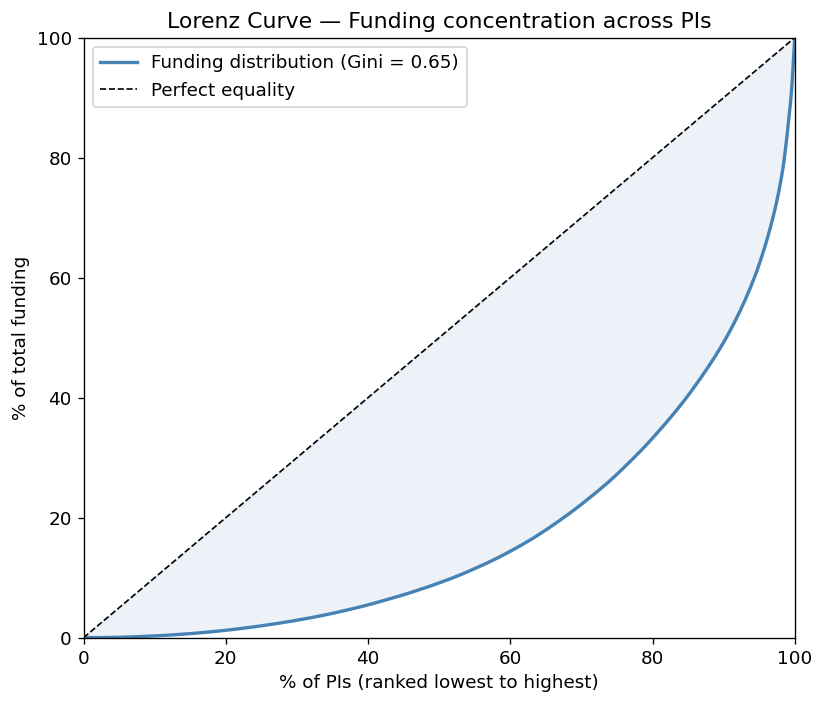

Gini coefficient: 0.646  (0 = perfect equality, 1 = one PI has everything)


In [27]:
# Lorenz curve — visualize funding inequality across PIs
# Diagonal = perfect equality; the further the curve bows down, the more concentrated funding is
sorted_funding = pi_funding.sort_values(ascending=True).values
n = len(sorted_funding)
lorenz_y = sorted_funding.cumsum() / sorted_funding.sum()
lorenz_x = np.arange(1, n+1) / n

# Gini coefficient
gini = 1 - 2 * np.trapz(lorenz_y, lorenz_x)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(lorenz_x * 100, lorenz_y * 100, color='steelblue', linewidth=2, label=f'Funding distribution (Gini = {gini:.2f})')
ax.plot([0, 100], [0, 100], 'k--', linewidth=1, label='Perfect equality')
ax.fill_between(lorenz_x * 100, lorenz_y * 100, lorenz_x * 100, alpha=0.1, color='steelblue')
ax.set_xlabel('% of PIs (ranked lowest to highest)')
ax.set_ylabel('% of total funding')
ax.set_title('Lorenz Curve — Funding concentration across PIs')
ax.legend()
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
#plt.savefig('lorenz_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Gini coefficient: {gini:.3f}  (0 = perfect equality, 1 = one PI has everything)')

# The x-axis is PIs ranked from lowest to highest funded (left = least funded, right = most funded)
# The y-axis is the cumulative share of total funding
# The diagonal line is what perfect equality would look like, the bottom 10% of PIs would hold 10% of money, bottom 50% would hold 50%, etc.
# Your actual curve bows below that diagonal, the further it bows, the more unequal the distribution

# The curve stays near zero for a long time (most PIs have very little) then shoots up steeply at the right end (a few PIs have a lot). 
# The area between the diagonal and the curve is what the Gini coefficient measure, bigger gap = higher Gini = more concentration.

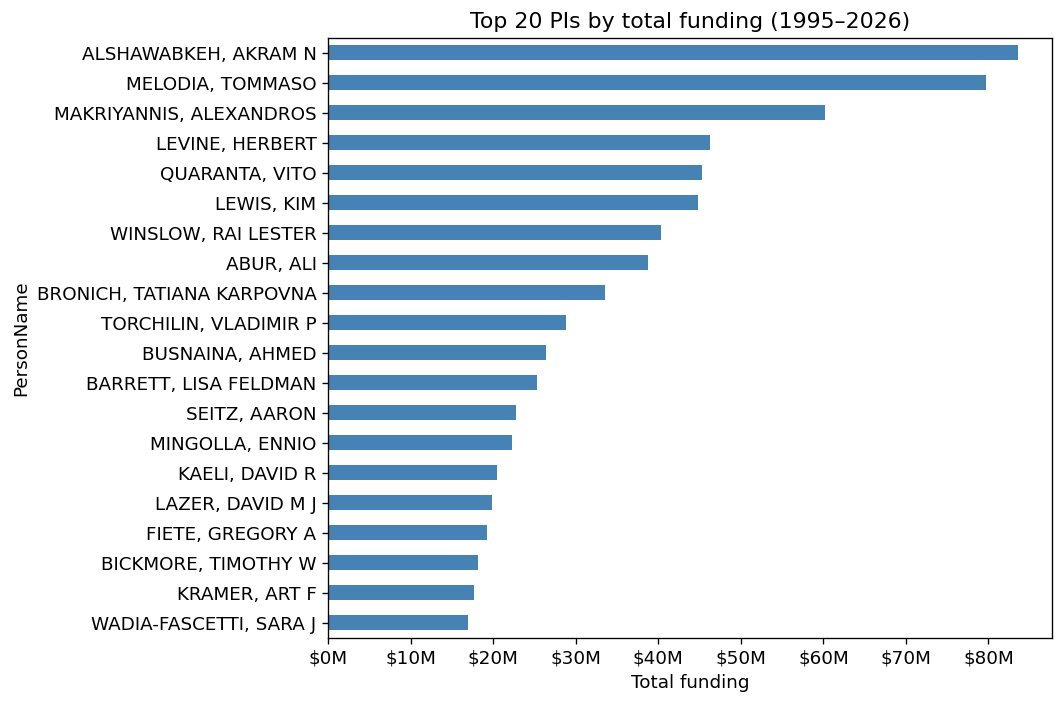

In [28]:
# Bar chart — top 20 PIs by total funding
top20 = pi_funding.head(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.set_xlabel('Total funding')
ax.set_title('Top 20 PIs by total funding (1995–2026)')
plt.tight_layout()
#plt.savefig('top20_pis.png', dpi=150, bbox_inches='tight')
plt.show()

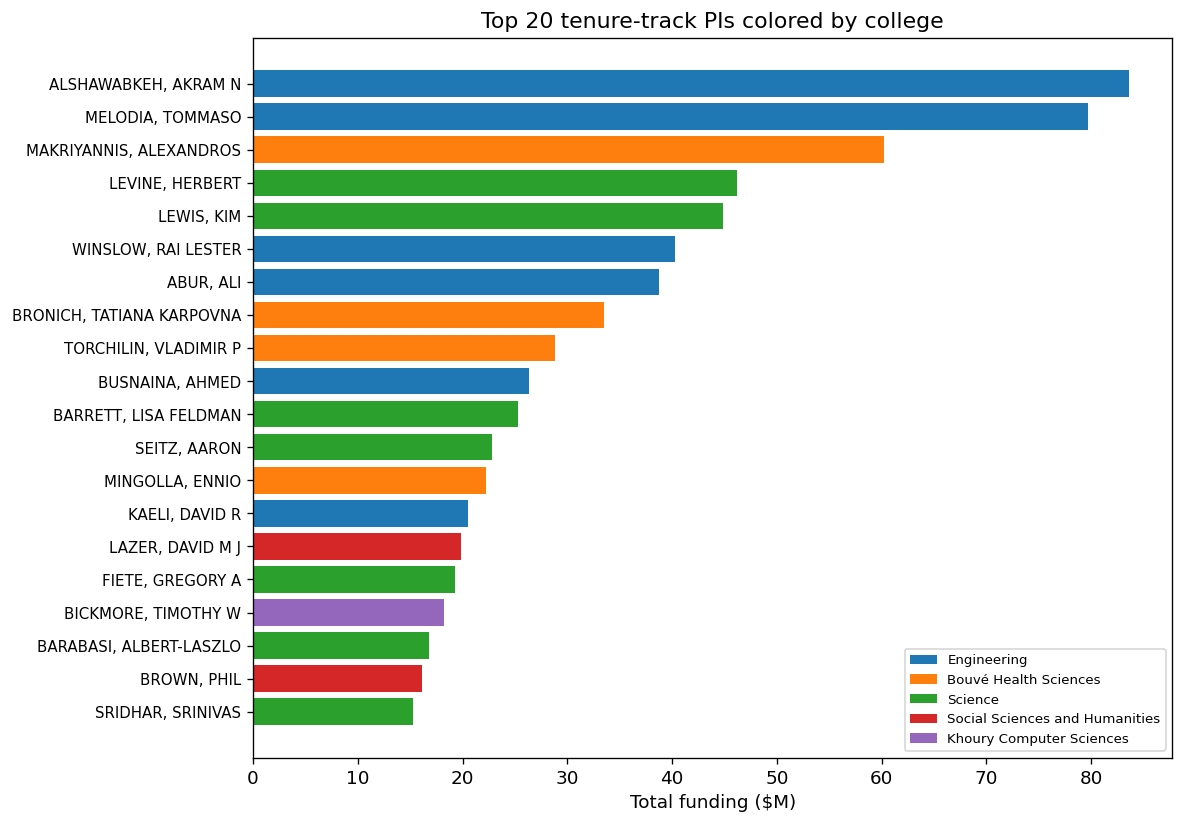

In [29]:
# Top 20 tenure-track PIs split by college — colored bar chart
copi_tenure = copi_research[copi_research['Academic Track Type'] == 'Tenure Track'].copy()

top20_pi = (
    copi_tenure
    .groupby('PersonName')['TotalDollars']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top20_names   = top20_pi.index.tolist()
top20_details = copi_tenure[copi_tenure['PersonName'].isin(top20_names)].copy()

top20_college = (
    top20_details
    .groupby(['PersonName','Superior_Academic_Unit'])['TotalDollars']
    .sum()
    .reset_index()
    .sort_values('TotalDollars', ascending=False)
)

colleges = top20_college['Superior_Academic_Unit'].unique()
colors   = dict(zip(colleges, plt.cm.tab10.colors[:len(colleges)]))

fig, ax = plt.subplots(figsize=(10, 7))
for i, name in enumerate(top20_pi.sort_values().index):
    row = top20_college[top20_college['PersonName'] == name].iloc[0]
    color = colors[row['Superior_Academic_Unit']]
    ax.barh(i, row['TotalDollars']/1e6, color=color)

ax.set_yticks(range(len(top20_pi.sort_values())))
ax.set_yticklabels(top20_pi.sort_values().index, fontsize=9)
ax.set_xlabel('Total funding ($M)')
ax.set_title('Top 20 tenure-track PIs colored by college')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[c], label=c.replace('College of ','').replace('Khoury College of ','Khoury/'))
                   for c in colleges]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
plt.tight_layout()
#plt.savefig('top20_tenure_pi_by_college.png', dpi=150, bbox_inches='tight')
plt.show()

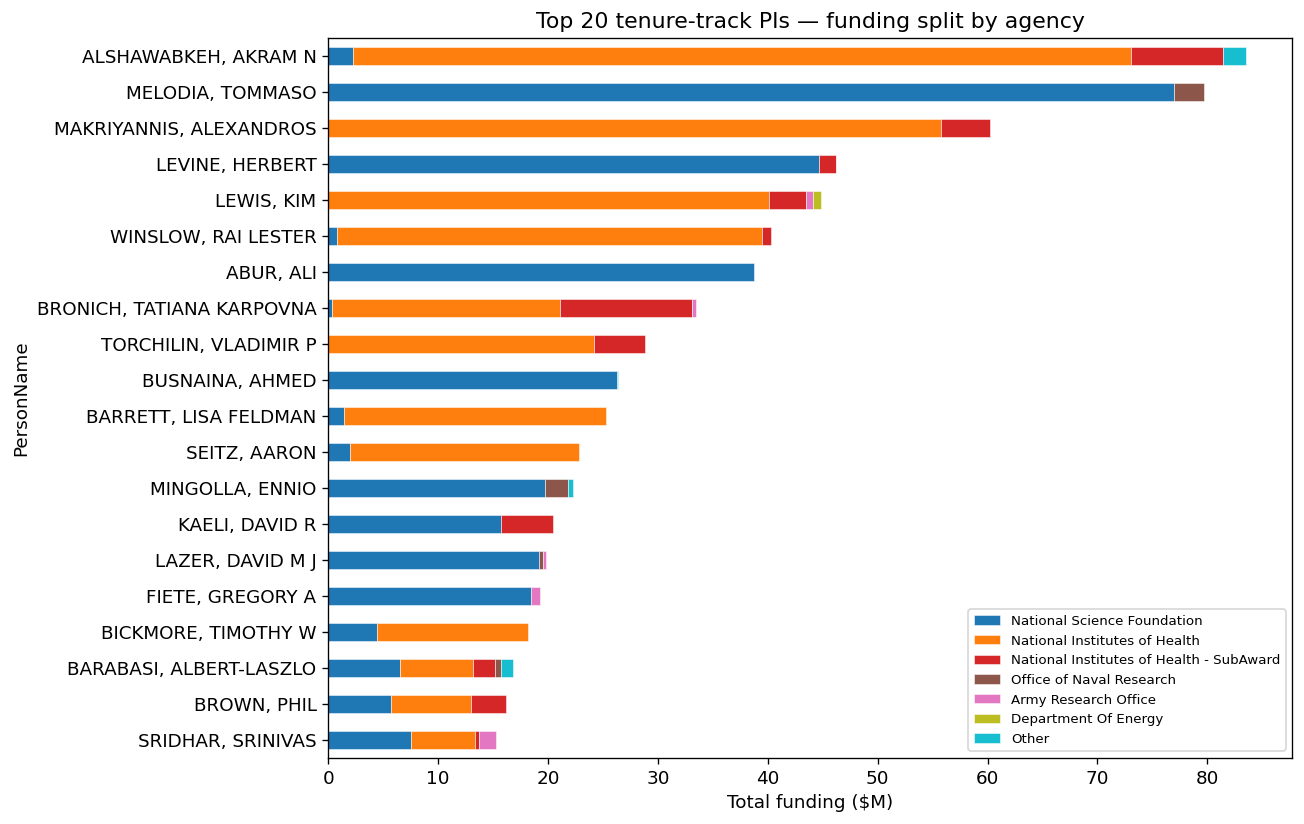

In [30]:
# Top 20 tenure-track PIs split by agency — stacked bar
top20_agency = (
    top20_details
    .groupby(['PersonName','AgencyName'])['TotalDollars']
    .sum()
    .unstack(fill_value=0)
)
# Keep top 6 agencies, group rest as 'Other'
top6_ag = copi_tenure['AgencyName'].value_counts().head(6).index
other_cols = [c for c in top20_agency.columns if c not in top6_ag]
top20_agency['Other'] = top20_agency[other_cols].sum(axis=1)
top20_agency = top20_agency[list(top6_ag) + ['Other']]
top20_agency = top20_agency.loc[top20_pi.sort_values().index]

fig, ax = plt.subplots(figsize=(11, 7))
(top20_agency / 1e6).plot(kind='barh', stacked=True, ax=ax,
                           colormap='tab10', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Total funding ($M)')
ax.set_title('Top 20 tenure-track PIs — funding split by agency')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('top20_tenure_pi_by_agency.png', dpi=150, bbox_inches='tight')
plt.show()

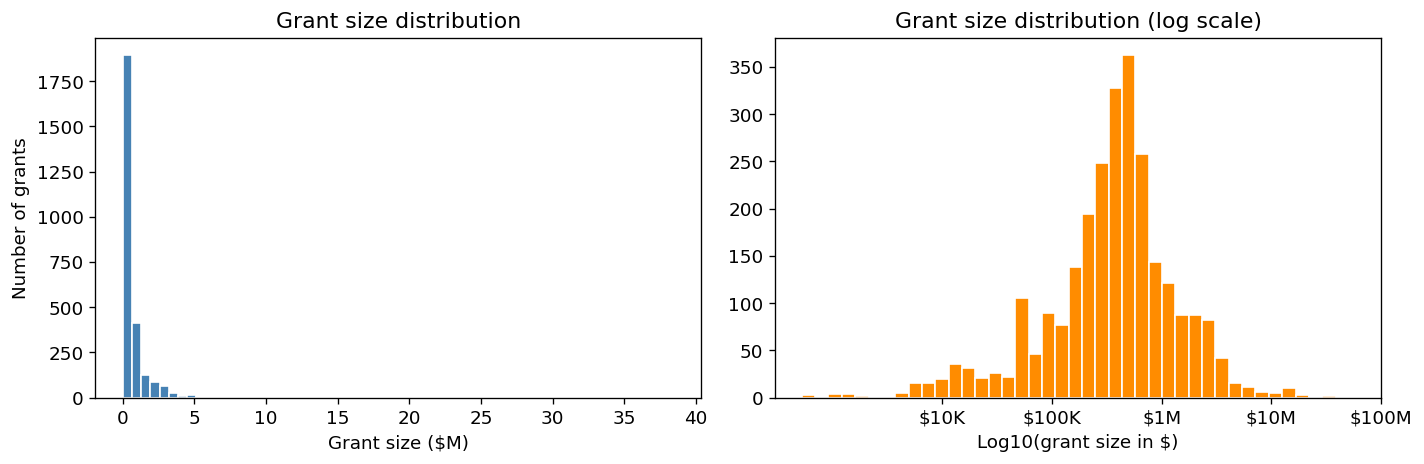

Grant size percentiles:
  10th percentile: $50,000
  25th percentile: $190,386
  50th percentile: $404,666
  75th percentile: $739,390
  90th percentile: $1,758,103
  95th percentile: $2,690,955
  99th percentile: $7,283,008


In [31]:
# Funding distribution histogram — what does a typical grant look like?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw distribution
axes[0].hist(copi_deduped['TotalDollars']/1e6, bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Grant size ($M)')
axes[0].set_ylabel('Number of grants')
axes[0].set_title('Grant size distribution')

# Log scale to see the full range
log_dollars = np.log10(copi_deduped['TotalDollars'].replace(0, np.nan).dropna())
axes[1].hist(log_dollars, bins=40, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Log10(grant size in $)')
axes[1].set_title('Grant size distribution (log scale)')
axes[1].set_xticks([4,5,6,7,8])
axes[1].set_xticklabels(['$10K','$100K','$1M','$10M','$100M'])

plt.tight_layout()
#plt.savefig('grant_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Grant size percentiles:')
for p in [10, 25, 50, 75, 90, 95, 99]:
    val = np.percentile(copi_deduped['TotalDollars'], p)
    print(f'  {p}th percentile: ${val:,.0f}')

## 2. College-Level Analysis — Raw and Normalized

In [32]:
# Raw funding per college: total dollars, number of grants, average grant size
college_raw = (
    copi_with_college
    .groupby('Superior_Academic_Unit', dropna=True)['TotalDollars']
    .agg(['sum','count','mean','median'])
    .rename(columns={'sum':'total_dollars','count':'num_grants','mean':'avg_grant','median':'median_grant'})
    .sort_values('total_dollars', ascending=False)
)
college_raw['total_M'] = college_raw['total_dollars'] / 1e6

print('Raw funding by college:')
print(college_raw[['num_grants','total_M','avg_grant','median_grant']].to_string())

Raw funding by college:
                                           num_grants  total_M    avg_grant  median_grant
Superior_Academic_Unit                                                                   
College of Engineering                            957   771.89   806,572.68    380,000.00
College of Science                                749   573.73   765,992.20    412,125.00
Bouvé College of Health Sciences                  275   367.71 1,337,117.24    554,974.00
Khoury College of Computer Sciences               359   214.49   597,459.72    449,831.00
College of Social Sciences and Humanities         115    65.37   568,459.97    199,651.00
College of Arts, Media and Design                  46    27.65   601,143.65    499,540.50
School of Law                                      10     8.98   898,362.00    211,212.00
College of Professional Studies                     4     5.04 1,259,413.00  1,196,433.00
D'Amore-McKim School of Business                    9     3.35   371,726.44 

In [33]:
# Count faculty per college from the faculty file (all tracks)
# Then count only tenure-track faculty per college (the ones expected to bring grants)
faculty_per_college = faculty.groupby('Superior_Academic_Unit').size().rename('total_faculty')
tenure_per_college  = (
    faculty[faculty['Academic Track Type'] == 'Tenure Track']
    .groupby('Superior_Academic_Unit').size()
    .rename('tenure_faculty')
)

print('Faculty per college (all tracks):')
print(faculty_per_college.sort_values(ascending=False).to_string())
print()
print('Tenure-track faculty per college:')
print(tenure_per_college.sort_values(ascending=False).to_string())

Faculty per college (all tracks):
Superior_Academic_Unit
College of Engineering                       356
College of Science                           332
College of Social Sciences and Humanities    304
Bouvé College of Health Sciences             269
D'Amore-McKim School of Business             215
College of Arts, Media and Design            210
Khoury College of Computer Sciences          210
Northeastern University London               126
College of Professional Studies              110
School of Law                                 58
Mills College at Northeastern                 40
Northeastern University                        2

Tenure-track faculty per college:
Superior_Academic_Unit
College of Engineering                       207
College of Science                           172
College of Social Sciences and Humanities    152
College of Arts, Media and Design            103
D'Amore-McKim School of Business              93
Bouvé College of Health Sciences              87
Kho

In [34]:
# Normalize funding by faculty count
# dollars_per_faculty = total funding / total faculty in that college
# dollars_per_tenure  = total funding / tenure-track faculty only
# grants_per_faculty  = number of grants / total faculty

college_norm = college_raw.join(faculty_per_college).join(tenure_per_college)
college_norm['dollars_per_faculty'] = college_norm['total_dollars'] / college_norm['total_faculty']
college_norm['dollars_per_tenure']  = college_norm['total_dollars'] / college_norm['tenure_faculty']
college_norm['grants_per_faculty']  = college_norm['num_grants']    / college_norm['total_faculty']
college_norm['grants_per_tenure']   = college_norm['num_grants']    / college_norm['tenure_faculty']

print('Normalized metrics per college:')
print(college_norm[['total_faculty','tenure_faculty','num_grants','total_M',
                     'dollars_per_faculty','dollars_per_tenure','grants_per_tenure']]
      .sort_values('dollars_per_tenure', ascending=False).to_string())

Normalized metrics per college:
                                           total_faculty  tenure_faculty  num_grants  total_M  dollars_per_faculty  dollars_per_tenure  grants_per_tenure
Superior_Academic_Unit                                                                                                                                   
College of Professional Studies                      110               1           4     5.04            45,796.84        5,037,652.00               4.00
Bouvé College of Health Sciences                     269              87         275   367.71         1,366,941.42        4,226,520.02               3.16
College of Engineering                               356             207         957   771.89         2,168,230.50        3,728,937.48               4.62
College of Science                                   332             172         749   573.73         1,728,096.86        3,335,628.83               4.35
Khoury College of Computer Sciences         

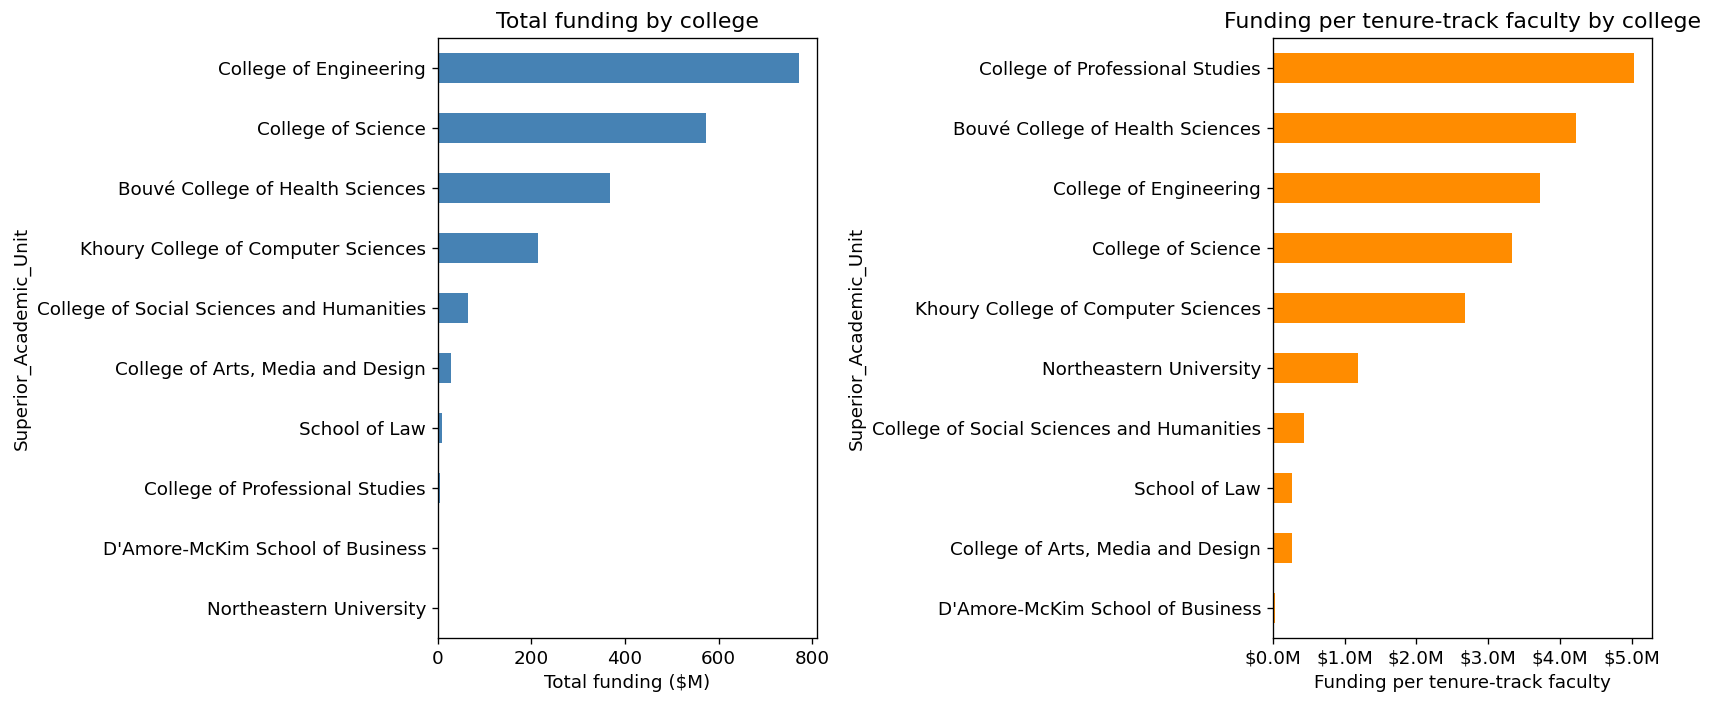

In [35]:
# Side-by-side: raw total funding vs funding per tenure-track faculty
# This reveals colleges that look small in absolute terms but are actually productive per person
plot_df = college_norm.dropna(subset=['dollars_per_tenure']).sort_values('total_M', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_df['total_M'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Total funding ($M)')
axes[0].set_title('Total funding by college')

plot_df.sort_values('dollars_per_tenure', ascending=True)['dollars_per_tenure'].plot(
    kind='barh', ax=axes[1], color='darkorange')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].set_xlabel('Funding per tenure-track faculty')
axes[1].set_title('Funding per tenure-track faculty by college')

plt.tight_layout()
#plt.savefig('college_funding_raw_vs_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

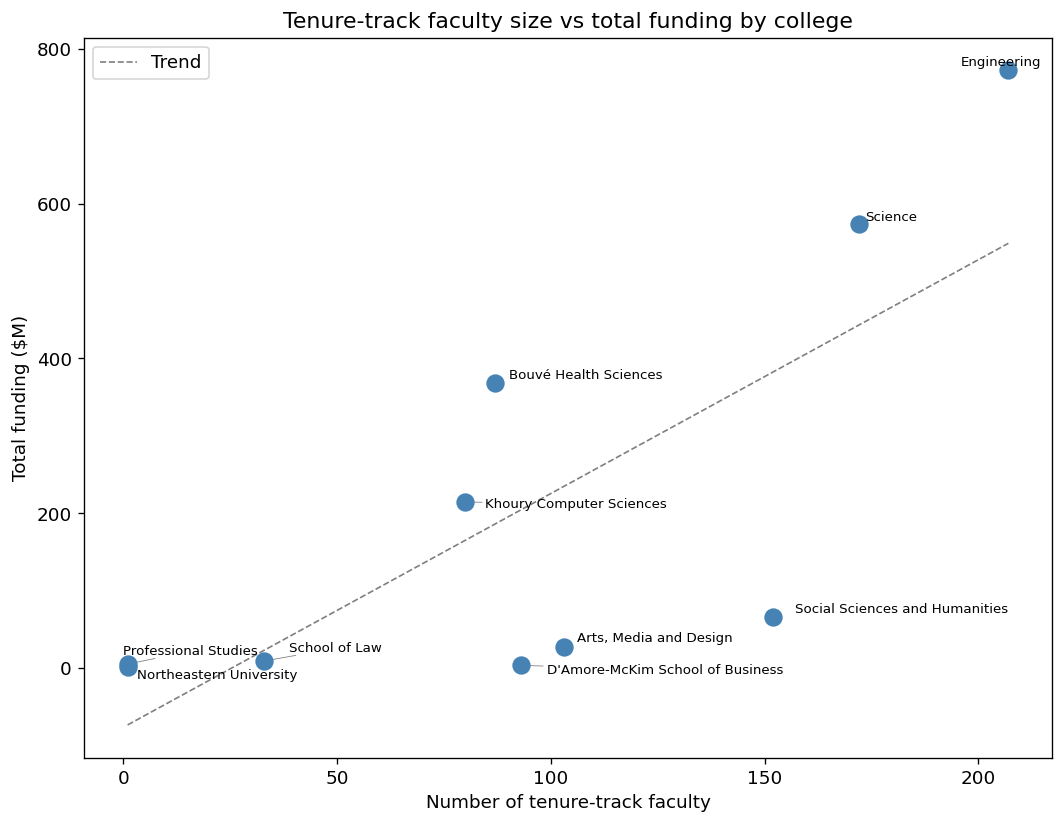

In [36]:
# Scatter: tenure-track faculty count vs total funding per college
# Shows which colleges are above/below the trend line
# Auto-adjust labels to avoid overlap using adjustText

from adjustText import adjust_text

plot_df2 = college_norm.dropna(subset=['tenure_faculty','total_M']).copy()

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(plot_df2['tenure_faculty'], plot_df2['total_M'], s=100, color='steelblue', zorder=3)

texts = []
for _, row in plot_df2.iterrows():
    label = row.name.replace('College of ','').replace('Khoury College of ','Khoury/')
    t = ax.text(row['tenure_faculty'], row['total_M'], label, fontsize=8)
    texts.append(t)

adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Trend line
z = np.polyfit(plot_df2['tenure_faculty'], plot_df2['total_M'], 1)
p = np.poly1d(z)
x_line = np.linspace(plot_df2['tenure_faculty'].min(), plot_df2['tenure_faculty'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', linewidth=1, alpha=0.5, label='Trend')

ax.set_xlabel('Number of tenure-track faculty')
ax.set_ylabel('Total funding ($M)')
ax.set_title('Tenure-track faculty size vs total funding by college')
ax.legend()
plt.tight_layout()
#plt.savefig('college_scatter_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Funding Agency Analysis

In [37]:
# Full agency breakdown: grant count, total funding, average grant
agency_summary = (
    copi_deduped
    .groupby('AgencyName')['TotalDollars']
    .agg(['count','sum','mean'])
    .rename(columns={'count':'num_grants','sum':'total_dollars','mean':'avg_grant'})
    .sort_values('num_grants', ascending=False)
)
agency_summary['total_M']    = agency_summary['total_dollars'] / 1e6
agency_summary['pct_grants'] = (agency_summary['num_grants'] / agency_summary['num_grants'].sum() * 100).round(1)
agency_summary['pct_dollars'] = (agency_summary['total_dollars'] / agency_summary['total_dollars'].sum() * 100).round(1)

print(agency_summary[['num_grants','pct_grants','total_M','pct_dollars','avg_grant']].to_string())

                                                        num_grants  pct_grants  total_M  pct_dollars    avg_grant
AgencyName                                                                                                       
National Science Foundation                                   1682       63.00 1,049.40        48.80   623,901.65
National Institutes of Health                                  546       20.40   833.00        38.80 1,525,633.78
National Institutes of Health - SubAward                       104        3.90    74.60         3.50   717,271.26
Office of Naval Research                                        87        3.30    59.69         2.80   686,084.85
National Aeronautics and Space Administration                   49        1.80    22.06         1.00   450,124.69
Army Research Office                                            48        1.80    13.18         0.60   274,675.54
Department Of Energy                                            37        1.40    33.84 

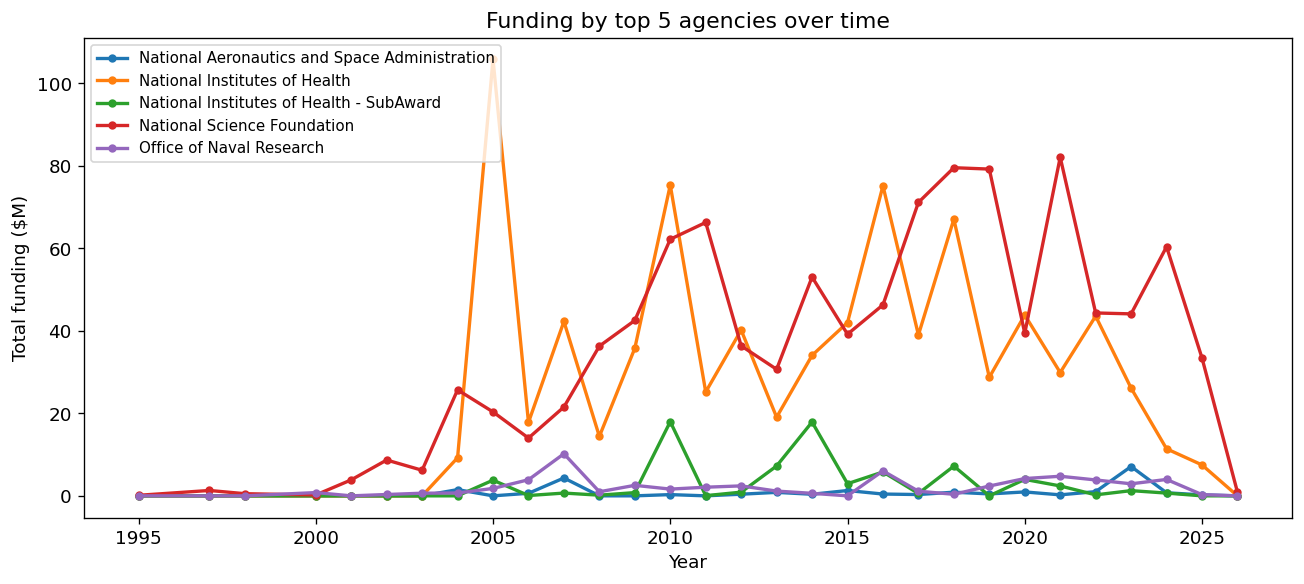

In [38]:
# Agency funding trend over time — top 5 agencies
top5_agencies = agency_summary.head(5).index.tolist()

agency_year = (
    copi_deduped[copi_deduped['AgencyName'].isin(top5_agencies)]
    .groupby(['StartDateYear','AgencyName'])['TotalDollars']
    .sum()
    .unstack(fill_value=0)
) / 1e6

fig, ax = plt.subplots(figsize=(11, 5))
agency_year.plot(ax=ax, linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Total funding ($M)')
ax.set_title('Funding by top 5 agencies over time')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
#plt.savefig('agency_trend.png', dpi=150, bbox_inches='tight')
plt.show()

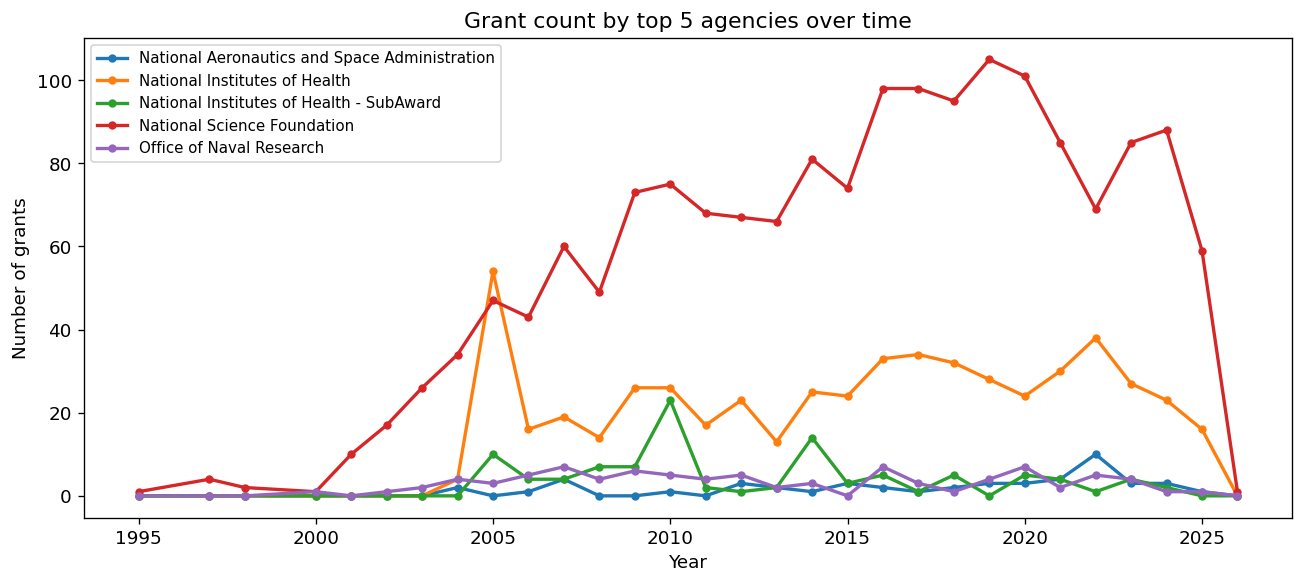

In [39]:
# Agency grant count trend over time — same top 5
agency_year_count = (
    copi_deduped[copi_deduped['AgencyName'].isin(top5_agencies)]
    .groupby(['StartDateYear','AgencyName'])['GrantId']
    .count()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 5))
agency_year_count.plot(ax=ax, linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Number of grants')
ax.set_title('Grant count by top 5 agencies over time')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
#plt.savefig('agency_count_trend.png', dpi=150, bbox_inches='tight')
plt.show()

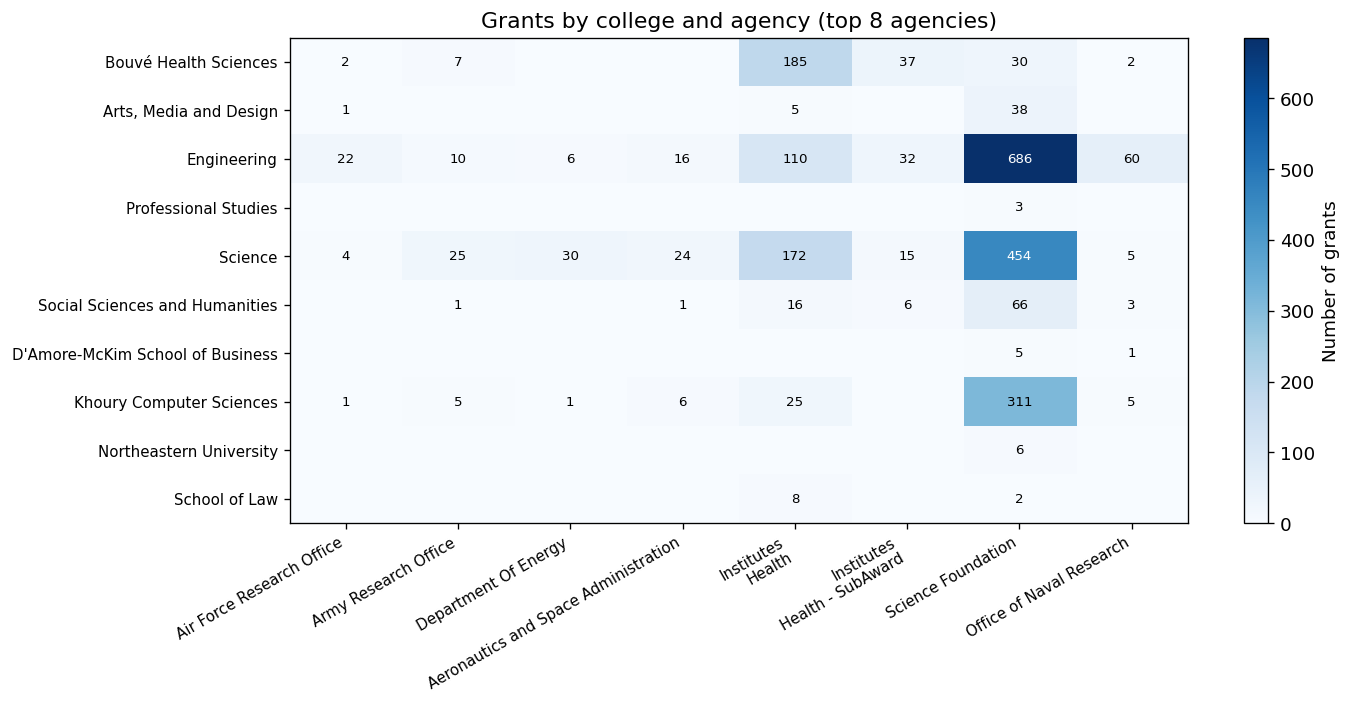

In [40]:
# Heatmap: college x agency — number of grants
college_agency = (
    copi_with_college
    .dropna(subset=['Superior_Academic_Unit'])
    .groupby(['Superior_Academic_Unit','AgencyName'])['GrantId']
    .count()
    .unstack(fill_value=0)
)
# Keep only top 8 agencies for readability
top8_agencies = agency_summary.head(8).index
college_agency_top = college_agency[college_agency.columns.intersection(top8_agencies)]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(college_agency_top.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(college_agency_top.columns)))
ax.set_xticklabels([c.replace('National ','').replace(' of Health','\nHealth') 
                    for c in college_agency_top.columns], rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(college_agency_top.index)))
ax.set_yticklabels([c.replace('College of ','').replace('Khoury College of ','') 
                    for c in college_agency_top.index], fontsize=9)
plt.colorbar(im, ax=ax, label='Number of grants')
ax.set_title('Grants by college and agency (top 8 agencies)')

# Add numbers in cells
for i in range(len(college_agency_top.index)):
    for j in range(len(college_agency_top.columns)):
        val = college_agency_top.values[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center', fontsize=8,
                    color='white' if val > college_agency_top.values.max()*0.5 else 'black')

plt.tight_layout()
#plt.savefig('heatmap_college_agency.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Funding Over Time

In [41]:
# Total grants and funding per year
grants_per_year  = copi_deduped.groupby('StartDateYear')['GrantId'].count().rename('num_grants')
dollars_per_year = copi_deduped.groupby('StartDateYear')['TotalDollars'].sum().rename('total_dollars') / 1e6
avg_per_year     = (copi_deduped.groupby('StartDateYear')['TotalDollars'].mean() / 1e6).rename('avg_grant_M')

yearly = pd.concat([grants_per_year, dollars_per_year, avg_per_year], axis=1)
print(yearly.to_string())

               num_grants  total_dollars  avg_grant_M
StartDateYear                                        
1995                    1           0.13         0.13
1997                    4           1.30         0.33
1998                    2           0.52         0.26
2000                    2           1.01         0.50
2001                   10           3.87         0.39
2002                   19          10.57         0.56
2003                   31           7.27         0.23
2004                   49          41.60         0.85
2005                  117         132.91         1.14
2006                   73          38.19         0.52
2007                  103          85.82         0.83
2008                   87          56.00         0.64
2009                  125          85.87         0.69
2010                  139         160.21         1.15
2011                  102          98.64         0.97
2012                  111          92.58         0.83
2013                   91   

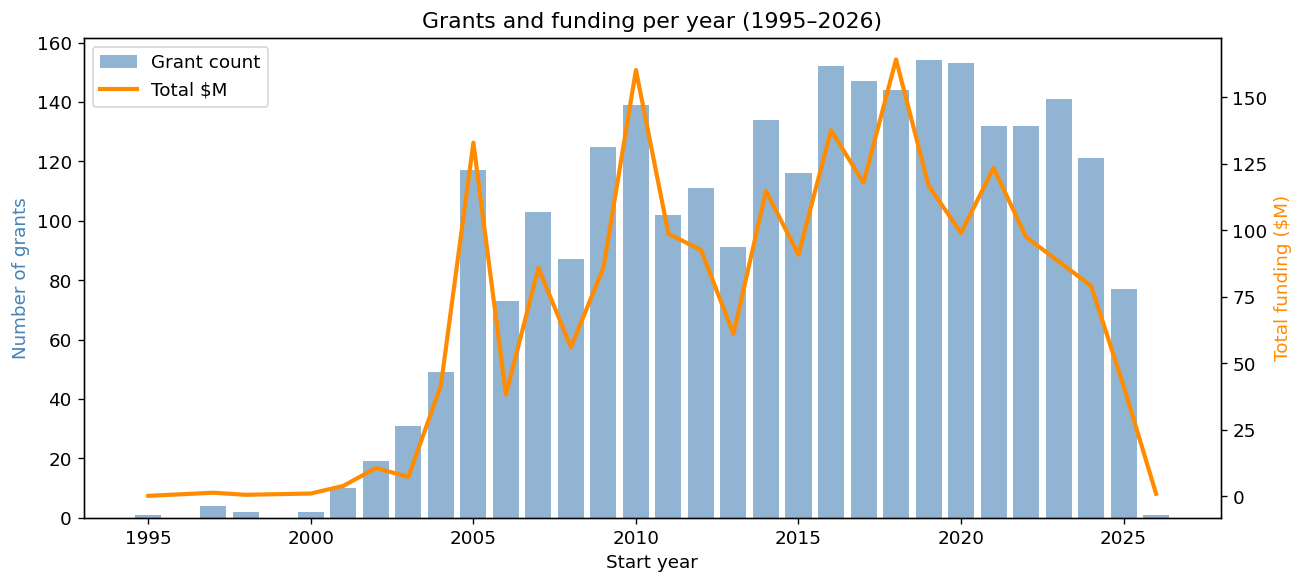

In [42]:
# Dual-axis chart: grant count and total dollars per year
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.bar(grants_per_year.index, grants_per_year.values, color='steelblue', alpha=0.6, label='Grant count')
ax2.plot(dollars_per_year.index, dollars_per_year.values, color='darkorange', linewidth=2.5, label='Total $M')

ax1.set_xlabel('Start year')
ax1.set_ylabel('Number of grants', color='steelblue')
ax2.set_ylabel('Total funding ($M)', color='darkorange')
ax1.set_title('Grants and funding per year (1995–2026)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
#plt.savefig('funding_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Co-PI Structure

In [43]:
# PI vs co-PI: count and funding comparison
role_summary = (
    copi
    .groupby('IsCoPI')['TotalDollars']
    .agg(['count','mean','median','sum'])
    .rename(index={0:'PI', 1:'Co-PI'})
)
role_summary['sum_M'] = role_summary['sum'] / 1e6

print('PI vs Co-PI comparison (pre-dedup, all rows):')
print(role_summary[['count','mean','median','sum_M']].to_string())

# TotalDollars is the same value for all people on one grant
# Co-PI grants appear larger because they are more often large collaborative projects.

PI vs Co-PI comparison (pre-dedup, all rows):
        count         mean     median    sum_M
IsCoPI                                        
PI       2366   742,417.71 399,616.50 1,756.56
Co-PI     770 1,168,063.25 584,079.00   899.41


In [44]:
# How many grants involve a co-PI vs are solo PI grants?
grants_with_copi = copi[copi['IsCoPI']==1]['GrantId'].nunique()
grants_solo      = copi_deduped['GrantId'].nunique() - grants_with_copi

print(f'Total unique grants              : {copi_deduped["GrantId"].nunique():,}')
print(f'Grants with at least one co-PI   : {grants_with_copi:,}  ({grants_with_copi/copi_deduped["GrantId"].nunique()*100:.1f}%)')
print(f'Solo PI grants (no co-PI)        : {grants_solo:,}  ({grants_solo/copi_deduped["GrantId"].nunique()*100:.1f}%)')

# Average grant size: collaborative vs solo
collab_grants = copi_deduped[copi_deduped['GrantId'].isin(copi[copi['IsCoPI']==1]['GrantId'])]
solo_grants   = copi_deduped[~copi_deduped['GrantId'].isin(copi[copi['IsCoPI']==1]['GrantId'])]

print()
print(f'Avg grant size — collaborative   : ${collab_grants["TotalDollars"].mean():,.0f}')
print(f'Avg grant size — solo PI         : ${solo_grants["TotalDollars"].mean():,.0f}')
print(f'Median — collaborative           : ${collab_grants["TotalDollars"].median():,.0f}')
print(f'Median — solo PI                 : ${solo_grants["TotalDollars"].median():,.0f}')

Total unique grants              : 2,670
Grants with at least one co-PI   : 598  (22.4%)
Solo PI grants (no co-PI)        : 2,072  (77.6%)

Avg grant size — collaborative   : $1,092,024
Avg grant size — solo PI         : $721,993
Median — collaborative           : $525,852
Median — solo PI                 : $378,662


In [45]:
# People who mostly appear as co-PIs vs leads
# For each person: what % of their grants are as co-PI?
person_roles = (
    copi
    .groupby('PersonName')['IsCoPI']
    .agg(['sum','count'])
    .rename(columns={'sum':'copi_count','count':'total_grants'})
)
person_roles['pct_copi'] = person_roles['copi_count'] / person_roles['total_grants'] * 100

always_copi  = person_roles[person_roles['pct_copi'] == 100]
mostly_copi  = person_roles[(person_roles['pct_copi'] >= 50) & (person_roles['pct_copi'] < 100)]
mostly_pi    = person_roles[person_roles['pct_copi'] == 0]

print(f'People who are always co-PI (never lead)  : {len(always_copi)}')
print(f'People who are mostly co-PI (>=50%)       : {len(mostly_copi)}')
print(f'People who are always lead PI             : {len(mostly_pi)}')
print()
print('Always co-PI people (sample):')
print(always_copi.sort_values('total_grants', ascending=False).head(10).to_string())

People who are always co-PI (never lead)  : 45
People who are mostly co-PI (>=50%)       : 79
People who are always lead PI             : 250

Always co-PI people (sample):
                         copi_count  total_grants  pct_copi
PersonName                                                 
HARRIS, RICHARD                   5             5    100.00
DING, AIDONG A                    4             4    100.00
WELLES, BROOKE FOUCAULT           3             3    100.00
MARTSINKOVSKY, ALEX               3             3    100.00
PARSONS, CHRIS MICHAEL            2             2    100.00
FERNANDEZ, LORETTA ANA            2             2    100.00
ALDRICH, DANIEL                   1             1    100.00
LEE-STRONACH, CHAD                1             1    100.00
LUSTIG, STEVE RAYMOND             1             1    100.00
MCCULLOUGH, ASTON K               1             1    100.00


Co-PI rate by college:
                                           total_rows  copi_pct
Superior_Academic_Unit                                         
College of Professional Studies                     4     50.00
College of Arts, Media and Design                  60     48.30
Northeastern University                             6     33.30
School of Law                                      12     33.30
College of Social Sciences and Humanities         142     31.70
D'Amore-McKim School of Business                   11     27.30
Khoury College of Computer Sciences               421     25.90
College of Engineering                           1145     25.50
College of Science                                870     21.60
Bouvé College of Health Sciences                  288     12.50


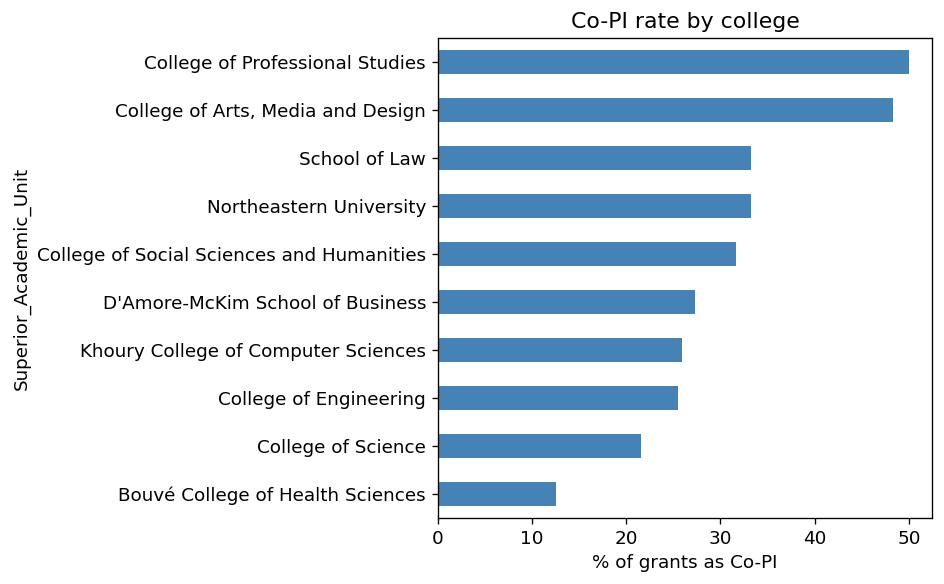

In [46]:
# Co-PI rate by college — which colleges collaborate more?
copi_by_college = (
    copi.merge(faculty_slim, on='ClientFacultyId', how='left')
    .dropna(subset=['Superior_Academic_Unit'])
    .groupby('Superior_Academic_Unit')['IsCoPI']
    .agg(['mean','count'])
    .rename(columns={'mean':'copi_rate','count':'total_rows'})
    .sort_values('copi_rate', ascending=False)
)
copi_by_college['copi_pct'] = (copi_by_college['copi_rate'] * 100).round(1)

print('Co-PI rate by college:')
print(copi_by_college[['total_rows','copi_pct']].to_string())

fig, ax = plt.subplots(figsize=(8, 5))
copi_by_college['copi_pct'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% of grants as Co-PI')
ax.set_title('Co-PI rate by college')
plt.tight_layout()
#plt.savefig('copi_rate_college.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Gap Analysis — Funded vs Unfunded Faculty

In [47]:
# Which current tenure-track faculty have no grants in the dataset?
tenure_faculty = faculty[faculty['Academic Track Type'] == 'Tenure Track'].copy()
funded_ids     = set(copi_deduped['ClientFacultyId'].values)

tenure_faculty['has_grant'] = tenure_faculty['Employee ID'].isin(funded_ids)

funded_count   = tenure_faculty['has_grant'].sum()
unfunded_count = (~tenure_faculty['has_grant']).sum()

print(f'Tenure-track faculty total : {len(tenure_faculty):,}')
print(f'  With grant records       : {funded_count:,}  ({funded_count/len(tenure_faculty)*100:.1f}%)')
print(f'  No grant record          : {unfunded_count:,}  ({unfunded_count/len(tenure_faculty)*100:.1f}%)')

Tenure-track faculty total : 958
  With grant records       : 486  (50.7%)
  No grant record          : 472  (49.3%)


Funded vs unfunded tenure-track faculty per college:
                                           funded  total  unfunded  funded_pct  unfunded_pct
Superior_Academic_Unit                                                                      
College of Professional Studies                 1      1         0      100.00          0.00
Northeastern University                         1      1         0      100.00          0.00
Khoury College of Computer Sciences            64     80        16       80.00         20.00
College of Engineering                        164    207        43       79.20         20.80
College of Science                            133    172        39       77.30         22.70
Bouvé College of Health Sciences               54     87        33       62.10         37.90
College of Social Sciences and Humanities      41    152       111       27.00         73.00
College of Arts, Media and Design              17    103        86       16.50         83.50
School of Law    

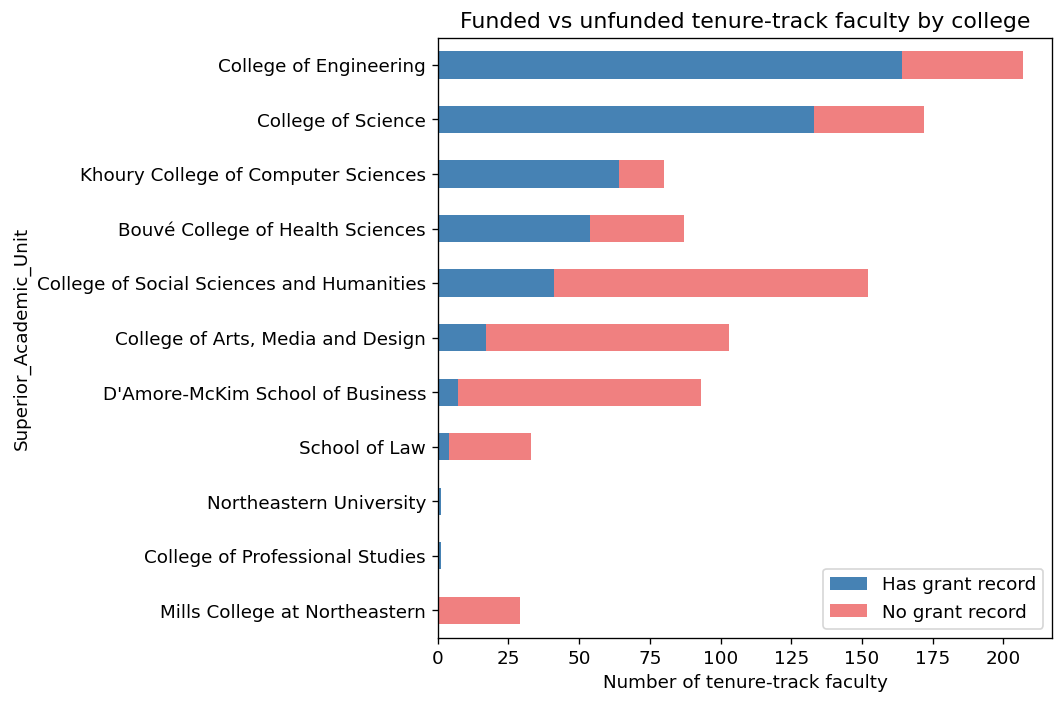

In [48]:
# Funded vs unfunded tenure-track faculty per college
gap_by_college = (
    tenure_faculty
    .groupby('Superior_Academic_Unit')['has_grant']
    .agg(['sum','count'])
    .rename(columns={'sum':'funded','count':'total'})
)
gap_by_college['unfunded']    = gap_by_college['total'] - gap_by_college['funded']
gap_by_college['funded_pct']  = (gap_by_college['funded']   / gap_by_college['total'] * 100).round(1)
gap_by_college['unfunded_pct'] = (gap_by_college['unfunded'] / gap_by_college['total'] * 100).round(1)
gap_by_college = gap_by_college.sort_values('funded_pct', ascending=False)

print('Funded vs unfunded tenure-track faculty per college:')
print(gap_by_college.to_string())

# Stacked bar
fig, ax = plt.subplots(figsize=(9, 6))
gap_plot = gap_by_college[['funded','unfunded']].sort_values('funded')
gap_plot.columns = ['Has grant record','No grant record']
gap_plot.plot(kind='barh', stacked=True, ax=ax,
              color=['steelblue','lightcoral'])
ax.set_xlabel('Number of tenure-track faculty')
ax.set_title('Funded vs unfunded tenure-track faculty by college')
ax.legend(loc='lower right')
plt.tight_layout()
#plt.savefig('gap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Grants per funded tenure-track PI:
count   532.00
mean      5.02
std       4.72
min       1.00
25%       2.00
50%       3.00
75%       7.00
max      35.00
Name: num_grants, dtype: float64

Distribution:
  >=  1 grants : 532 people
  >=  2 grants : 412 people
  >=  5 grants : 215 people
  >= 10 grants : 78 people
  >= 20 grants : 9 people


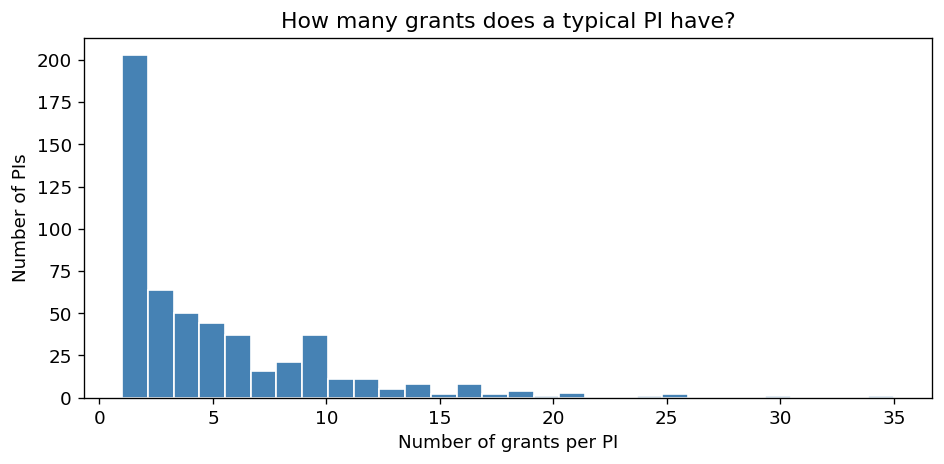

In [49]:
# Among funded tenure-track faculty: distribution of number of grants per person
grants_per_person = (
    copi_deduped
    .groupby('ClientFacultyId')['GrantId']
    .count()
    .rename('num_grants')
)

print('Grants per funded tenure-track PI:')
print(grants_per_person.describe())
print()
print('Distribution:')
for threshold in [1, 2, 5, 10, 20]:
    n = (grants_per_person >= threshold).sum()
    print(f'  >= {threshold:2d} grants : {n} people')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(grants_per_person.values, bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of grants per PI')
ax.set_ylabel('Number of PIs')
ax.set_title('How many grants does a typical PI have?')
plt.tight_layout()
#plt.savefig('grants_per_pi.png', dpi=150, bbox_inches='tight')
plt.show()

In [50]:
# Summary table
print(' SUMMARY')
print(f'  Total unique grants          : {len(copi_deduped):,}')
print(f'  Total funding (deduped)      : ${copi_deduped["TotalDollars"].sum()/1e6:,.1f}M')
print(f'  Unique PIs                   : {len(pi_funding):,}')
print(f'  Gini coefficient             : {gini:.3f}')
print(f'  PIs for top 80% of funding   : {top80_count} / {len(pi_funding)}')
print(f'  Top agency (NSF)             : {agency_summary.iloc[0]["pct_grants"]:.1f}% of grants')
print(f'  Top college (Engineering)    : {college_raw.iloc[0]["total_M"]:.1f}M total')
print(f'  Collaborative grants         : {grants_with_copi:,} ({grants_with_copi/copi_deduped["GrantId"].nunique()*100:.1f}%)')
print(f'  Tenure-track with grants     : {funded_count} / {len(tenure_faculty)} ({funded_count/len(tenure_faculty)*100:.1f}%)')

 SUMMARY
  Total unique grants          : 2,670
  Total funding (deduped)      : $2,149.0M
  Unique PIs                   : 532
  Gini coefficient             : 0.646
  PIs for top 80% of funding   : 173 / 532
  Top agency (NSF)             : 63.0% of grants
  Top college (Engineering)    : 771.9M total
  Collaborative grants         : 598 (22.4%)
  Tenure-track with grants     : 486 / 958 (50.7%)


In [51]:
# Filter faculty to research-active ranks only
# Keep: Professor, Associate Professor, Assistant Professor (all variants including UK and Research)
# Exclude: Teaching professors, Coop coordinators, Lecturers, Clinical, Visiting, Staff

research_ranks = [
    'Professor',
    'Associate Professor',
    'Assistant Professor',
    'Assistant Professor -UK',
    'Associate Professor -UK',
    'Full Professor -UK',
    'Assistant Research Professor',
    'Associate Research Professor',
    'Research Professor',
]

faculty_research = faculty[faculty['Academic Rank'].isin(research_ranks)].copy()

print(f'All faculty              : {len(faculty):,}')
print(f'Research-active faculty  : {len(faculty_research):,}')
print()
print('Breakdown by rank:')
print(faculty_research['Academic Rank'].value_counts().to_string())
print()
print('Breakdown by college:')
print(faculty_research['Superior_Academic_Unit'].value_counts().to_string())

All faculty              : 2,232
Research-active faculty  : 1,134

Breakdown by rank:
Academic Rank
Professor                       433
Associate Professor             268
Assistant Professor             257
Assistant Professor -UK          75
Associate Professor -UK          48
Assistant Research Professor     25
Associate Research Professor     14
Research Professor                7
Full Professor -UK                7

Breakdown by college:
Superior_Academic_Unit
College of Engineering                       219
College of Science                           190
College of Social Sciences and Humanities    160
Northeastern University London               116
College of Arts, Media and Design            105
Bouvé College of Health Sciences             101
D'Amore-McKim School of Business              93
Khoury College of Computer Sciences           84
School of Law                                 34
Mills College at Northeastern                 30
College of Professional Studies         

In [52]:
# Build clean deduped grants joined to research-active faculty only
faculty_slim = faculty_research[['Employee ID','Superior_Academic_Unit','Academic Rank','Academic Track Type']].rename(
    columns={'Employee ID':'ClientFacultyId'})

copi_deduped = copi.sort_values(['GrantId','IsCoPI']).drop_duplicates(subset='GrantId', keep='first').copy()
copi_research = copi_deduped.merge(faculty_slim, on='ClientFacultyId', how='inner')  # inner = only research faculty

print(f'Grants linked to research-active faculty : {len(copi_research):,}')
print(f'Total funding                            : ${copi_research["TotalDollars"].sum()/1e6:,.1f}M')
print(f'Unique PIs                               : {copi_research["PersonName"].nunique():,}')

Grants linked to research-active faculty : 2,508
Total funding                            : $1,990.0M
Unique PIs                               : 501


In [53]:
# Research faculty count per college — denominator for normalization
faculty_per_college = faculty_research.groupby('Superior_Academic_Unit').size().rename('research_faculty')
print('Research faculty per college:')
print(faculty_per_college.sort_values(ascending=False).to_string())

Research faculty per college:
Superior_Academic_Unit
College of Engineering                       219
College of Science                           190
College of Social Sciences and Humanities    160
Northeastern University London               116
College of Arts, Media and Design            105
Bouvé College of Health Sciences             101
D'Amore-McKim School of Business              93
Khoury College of Computer Sciences           84
School of Law                                 34
Mills College at Northeastern                 30
College of Professional Studies                1
Northeastern University                        1


In [54]:
# Average funding per PI per college, normalized by research faculty count
pi_college_funding = (
    copi_research
    .groupby(['Superior_Academic_Unit','PersonName'])['TotalDollars']
    .sum()
    .reset_index()
    .rename(columns={'TotalDollars':'pi_total'})
)

college_stats = (
    pi_college_funding
    .groupby('Superior_Academic_Unit')['pi_total']
    .agg(['sum','mean','median','count'])
    .rename(columns={'sum':'total_dollars','mean':'avg_per_pi','median':'median_per_pi','count':'num_funded_pis'})
)
college_stats['total_M'] = (college_stats['total_dollars'] / 1e6).round(1)
college_stats = college_stats.join(faculty_per_college)
college_stats['dollars_per_research_faculty'] = college_stats['total_dollars'] / college_stats['research_faculty']
college_stats['funded_pct'] = (college_stats['num_funded_pis'] / college_stats['research_faculty'] * 100).round(1)

print('College funding stats (research faculty only):')
print(college_stats[['research_faculty','num_funded_pis','funded_pct','total_M',
                      'avg_per_pi','dollars_per_research_faculty']].sort_values('total_M', ascending=False).to_string())

College funding stats (research faculty only):
                                           research_faculty  num_funded_pis  funded_pct  total_M   avg_per_pi  dollars_per_research_faculty
Superior_Academic_Unit                                                                                                                     
College of Engineering                                  219             165       75.30   771.60 4,676,307.58                  3,523,245.44
College of Science                                      190             138       72.60   573.70 4,157,450.43                  3,019,621.89
Bouvé College of Health Sciences                        101              61       60.40   322.30 5,283,993.61                  3,191,322.87
Khoury College of Computer Sciences                      84              65       77.40   211.60 3,254,700.26                  2,518,518.06
College of Social Sciences and Humanities               160              41       25.60    65.40 1,594,460.90    

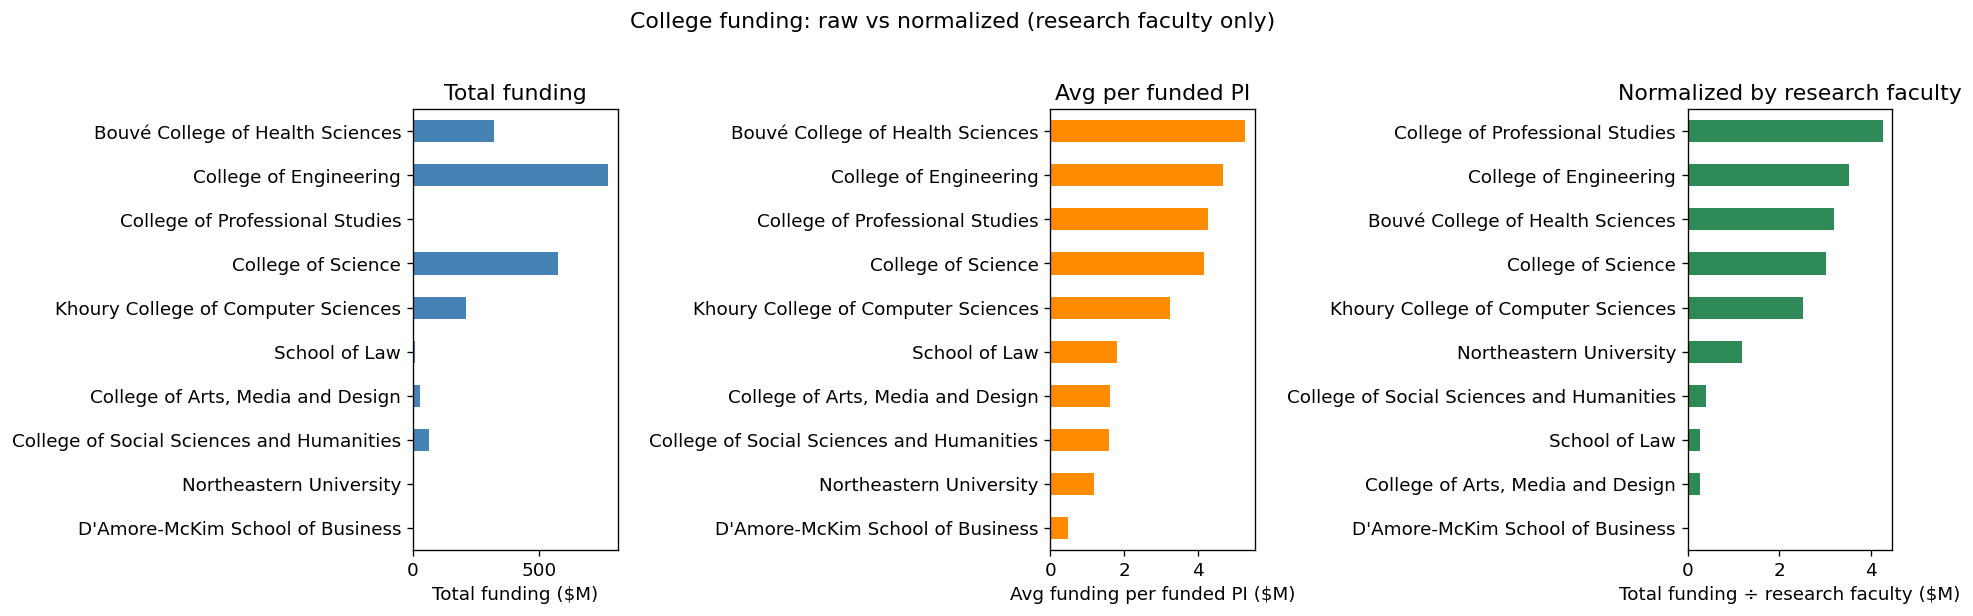

In [55]:
# Chart: avg funding per PI vs funding per research faculty — side by side per college
plot_df = college_stats.dropna().sort_values('avg_per_pi', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Total funding
plot_df['total_M'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Total funding ($M)')
axes[0].set_title('Total funding')

# Avg per funded PI
(plot_df['avg_per_pi'] / 1e6).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_xlabel('Avg funding per funded PI ($M)')
axes[1].set_title('Avg per funded PI')

# Normalized by all research faculty (including unfunded)
(plot_df['dollars_per_research_faculty'] / 1e6).sort_values().plot(kind='barh', ax=axes[2], color='seagreen')
axes[2].set_xlabel('Total funding ÷ research faculty ($M)')
axes[2].set_title('Normalized by research faculty')

for ax in axes:
    ax.set_ylabel('')

plt.suptitle('College funding: raw vs normalized (research faculty only)', y=1.02)
plt.tight_layout()
#plt.savefig('college_funding_normalized.png', dpi=150, bbox_inches='tight')
plt.show()